### 강화학습 Q-Learning

In [1]:
# gymnasium 라이브러리 설치
# !pip install gymnasium

In [2]:
# render_mode="human"을 확인하기위해
# !pip install pygame

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# 4X4 미로를 만들어서 출발점부터 목적지에 가는 방법을 학습
# 중간에 H(구멍)을 만나면 처음부터(시작점으로 이동)
# 환경 설정
env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=False, render_mode="rgb_array")

In [4]:
# Q-Table 초기화 (상태 16개 x 행동 4개)
# 상태 16개가 맵 4x4에 해당. 행동은 왼쪽, 아래, 오른쪽, 위 이동을 의미
q_table = np.zeros([env.observation_space.n, env.action_space.n])

In [5]:
# 하이퍼파라미터 설정
learning_rate = 0.1   # 학습률 (알파)
discount_rate = 0.99  # 할인율 (감마: 미래 보상의 가치)
episodes = 2000       # 총 연습 횟수
epsilon = 1.0         # 탐험(Exploration) 확률
epsilon_decay = 0.999 # 갈수록 탐험을 줄임
min_epsilon = 0.01

In [6]:
rewards_per_episode = []

print("학습을 시작합니다...")

# 3. 메인 학습 루프
for i in range(episodes):
		# 게임 판을 초기 상태로 되돌리고, 에이전트를 시작지점에 배치
    state, _ = env.reset()
    done = False
    total_reward = 0
    
    while not done:
        # 탐험 vs 이용 결정 (Epsilon-Greedy 방식)
        if np.random.random() < epsilon:
            action = env.action_space.sample() # 무작위 탐험
        else:
            # 현재 위치(state)의 Q-Table 행에서 가정 점수가 높은 행동의 인덱스를 찾아냄
            action = np.argmax(q_table[state, :]) # 아는 길로 가기(이용)
            
        # 행동 수행 및 결과 관찰
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # Q-Table 업데이트 (벨만 방정식 적용)
        # 현재 점수 = 이전 점수 + 학습률 * (보상 + 미래 예측 점수 - 이전 점수)
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state, :])
        
        new_value = old_value + learning_rate * (reward + discount_rate * next_max - old_value)
        q_table[state, action] = new_value
        
        state = next_state
        total_reward += reward
        
    # 탐험 확률 감소
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)

    if (i + 1) % 500 == 0:
        print(f"에피소드: {i+1}/{episodes} 완료")

print("학습 완료!")

학습을 시작합니다...
에피소드: 500/2000 완료
에피소드: 1000/2000 완료
에피소드: 1500/2000 완료
에피소드: 2000/2000 완료
학습 완료!


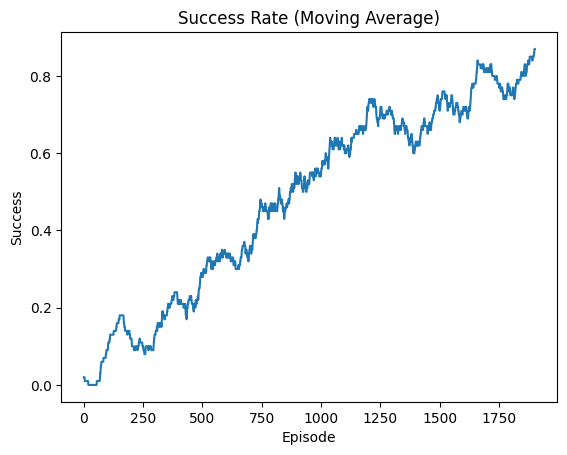

In [7]:
# 결과 시각화 (성공률 변화 확인)
plt.plot(np.convolve(rewards_per_episode, np.ones(100)/100, mode='valid'))
plt.title('Success Rate (Moving Average)')
plt.xlabel('Episode')
plt.ylabel('Success')
plt.show()

In [8]:
print("\n[최종 Q-Table (공략집)]")
print("왼쪽         아래         오른쪽        위")
print(q_table)


[최종 Q-Table (공략집)]
왼쪽         아래         오른쪽        위
[[0.94148015 0.95099005 0.93206506 0.94148015]
 [0.94148011 0.         0.79901497 0.84589762]
 [0.66564555 0.94595132 0.08973291 0.50992921]
 [0.36896926 0.         0.00376712 0.00569417]
 [0.95098996 0.96059601 0.         0.94148004]
 [0.         0.         0.         0.        ]
 [0.         0.98009694 0.         0.69266283]
 [0.         0.         0.         0.        ]
 [0.96059511 0.         0.970299   0.95098992]
 [0.96058568 0.98009123 0.9801     0.        ]
 [0.97029135 0.99       0.         0.97026867]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.88038721 0.98999999 0.91278378]
 [0.9799773  0.98998596 1.         0.9800882 ]
 [0.         0.         0.         0.        ]]
